In [19]:
import numpy as np
import matplotlib.pyplot as plt


In [20]:

# =================================================
# Custom Environment
# =================================================

grid = [
    "FFFS",
    "FHFF",
    "FFHF",
    "GFFF"
]
start_state = 3
goal_state = 12
holes = [5, 10]

num_states = 16
num_actions = 4

In [21]:

# =================================================
# Hyperparameters
# =================================================

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

In [22]:
# =================================================
# Q-table
# =================================================

Q = np.zeros((num_states, num_actions))

episode_rewards = []


# =================================================
# Epsilon-Greedy
# =================================================

def epsilon_greedy_action(state, epsilon):

    if np.random.random() < epsilon:
        return np.random.randint(num_actions)

    max_q = np.max(Q[state])

    best_actions = np.flatnonzero(
        Q[state] == max_q
    )

    return np.random.choice(best_actions)

In [23]:
# =================================================
# Environment Step
# =================================================

def step(state, action):

    row = state // 4
    col = state % 4

    # 0 = Left
    # 1 = Down
    # 2 = Right
    # 3 = Up

    if action == 0:
        col -= 1
    elif action == 1:
        row += 1
    elif action == 2:
        col += 1
    elif action == 3:
        row -= 1

    # Keep inside grid
    row = max(0, min(3, row))
    col = max(0, min(3, col))

    next_state = row * 4 + col

    # Goal
    if next_state == goal_state:
        return next_state, 1.0, True

    # Hole
    if next_state in holes:
        return next_state, -1.0, True

    # Normal movement
    return next_state, -0.01, False

In [24]:

# =================================================
# SARSA Training
# =================================================

for episode in range(num_episodes):

    state = start_state

    action = epsilon_greedy_action(
        state,
        epsilon
    )

    total_reward = 0

    for step_count in range(max_steps_per_episode):

        next_state, reward, done = step(
            state,
            action
        )

        total_reward += reward

        # Terminal state
        if done:

            Q[state, action] += alpha * (
                reward - Q[state, action]
            )

            break

        # Choose next action
        next_action = epsilon_greedy_action(
            next_state,
            epsilon
        )

        # SARSA update
        Q[state, action] += alpha * (
            reward
            + gamma * Q[next_state, next_action]
            - Q[state, action]
        )

        state = next_state
        action = next_action

    episode_rewards.append(total_reward)

    # Epsilon decay
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )



Custom Environment:
F F F S
F H F F
F F H F
G F F F

Final Q-table:
[[ 0.809  0.958  0.719  0.803]
 [ 0.938 -1.     0.783  0.83 ]
 [ 0.891  0.521  0.671  0.728]
 [ 0.851  0.607  0.653  0.698]
 [ 0.909  0.98  -1.     0.918]
 [ 0.     0.     0.     0.   ]
 [-1.    -1.     0.458  0.662]
 [ 0.328  0.394  0.414  0.708]
 [ 0.979  1.     0.952  0.949]
 [ 0.979  0.795 -0.991 -0.99 ]
 [ 0.     0.     0.     0.   ]
 [-1.     0.636 -0.176 -0.199]
 [ 0.     0.     0.     0.   ]
 [ 1.     0.826  0.38   0.153]
 [ 0.915  0.306  0.146 -1.   ]
 [ 0.789  0.298  0.192 -0.212]]

Estimated State-Value Function:
[[0.958 0.938 0.891 0.851]
 [0.98  0.    0.662 0.708]
 [1.    0.979 0.    0.636]
 [0.    1.    0.915 0.789]]

Learned Policy:
↓ ← ← S 
↓ H ↑ ↑ 
↓ ← H ↓ 
G ← ← ← 

Average reward over last 1000 episodes: 0.877


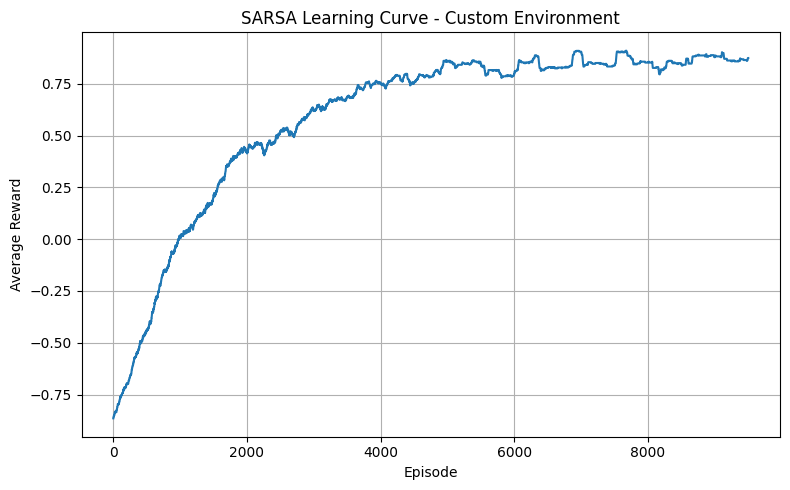

In [25]:


# =================================================
# State-Value Function
# =================================================

state_values = np.max(Q, axis=1)


# =================================================
# Learned Policy
# =================================================

learned_policy = np.argmax(Q, axis=1)


# =================================================
# Output
# =================================================

print("\nCustom Environment:")

for row in grid:
    print(" ".join(row))


print("\nFinal Q-table:")
print(np.round(Q, 3))


print("\nEstimated State-Value Function:")
print(
    np.round(
        state_values.reshape(4, 4),
        3
    )
)


# =================================================
# Policy Display
# =================================================

action_symbols = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

print("\nLearned Policy:")

for state in range(num_states):

    if state == start_state:
        symbol = "S"

    elif state == goal_state:
        symbol = "G"

    elif state in holes:
        symbol = "H"

    else:
        symbol = action_symbols[
            learned_policy[state]
        ]

    print(symbol, end=" ")

    if (state + 1) % 4 == 0:
        print()


# =================================================
# Average Reward
# =================================================

average_reward = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    round(average_reward, 3)
)


# =================================================
# Learning Curve
# =================================================

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "SARSA Learning Curve - Custom Environment"
)

plt.grid(True)
plt.tight_layout()
plt.show()
